## EDA 

Análise exploratória do dataset application_train.csv, focado em encontrar variáveis que sirvam como features para um modelo preditivo

In [1]:
from src.config import DIR_ROOT, DATA_DIR_RAW
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from src.visualization.eda import plot_target_by_decile


## Leitura inicial dos dados

leitura do csv e obervação inicial dos dados

In [2]:
df_application_train = pd.read_csv(DATA_DIR_RAW / "application_train.csv")

In [3]:
#Visualização inicial dos dados
df_application_train.head(10)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#Visualizando valores nulos e colunas
df_application_train.isnull().mean()

SK_ID_CURR                    0.000000
TARGET                        0.000000
NAME_CONTRACT_TYPE            0.000000
CODE_GENDER                   0.000000
FLAG_OWN_CAR                  0.000000
                                ...   
AMT_REQ_CREDIT_BUREAU_DAY     0.135016
AMT_REQ_CREDIT_BUREAU_WEEK    0.135016
AMT_REQ_CREDIT_BUREAU_MON     0.135016
AMT_REQ_CREDIT_BUREAU_QRT     0.135016
AMT_REQ_CREDIT_BUREAU_YEAR    0.135016
Length: 122, dtype: float64

In [5]:
#Informações sobre o dataset
# 307511 linhas e 122 colunas
df_application_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [6]:
df_application_train['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [7]:

numeric_columns = df_application_train.select_dtypes(include=np.number).columns

print(f'Colunas numéricas: {len(numeric_columns)}')

categoric_columns = df_application_train.select_dtypes(include='str').columns
print(f'Colunas categóricas: {len(categoric_columns)}')

Colunas numéricas: 106
Colunas categóricas: 16


In [8]:
# Colunas numéricas com valores nulos em ordem decrescente
df_aux = df_application_train[numeric_columns].isnull().mean()
display(df_aux.sort_values(ascending=False).head(10))

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_AVG               0.678486
dtype: float64

In [9]:
# Colunas categóricas com valores nulos em ordem decrescente
df_aux_categoricas = df_application_train[categoric_columns].isnull().mean()
display(df_aux_categoricas.sort_values(ascending=False).head(10))

FONDKAPREMONT_MODE     0.683862
WALLSMATERIAL_MODE     0.508408
HOUSETYPE_MODE         0.501761
EMERGENCYSTATE_MODE    0.473983
OCCUPATION_TYPE        0.313455
NAME_TYPE_SUITE        0.004201
FLAG_OWN_CAR           0.000000
NAME_CONTRACT_TYPE     0.000000
NAME_FAMILY_STATUS     0.000000
NAME_EDUCATION_TYPE    0.000000
dtype: float64

In [10]:
df_bureau = pd.read_csv(DATA_DIR_RAW / "bureau.csv")

In [11]:
# Descrição das colunas do dataset
desc = pd.read_csv(DATA_DIR_RAW / "HomeCredit_columns_description.csv", encoding='latin-1')
desc[desc["Table"] == "application_{train|test}.csv"][["Row", "Description"]].head(50)


,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
5,FLAG_OWN_REALTY,Flag if client owns a house or flat
6,CNT_CHILDREN,Number of children the client has
7,AMT_INCOME_TOTAL,Income of the client
8,AMT_CREDIT,Credit amount of the loan
9,AMT_ANNUITY,Loan annuity


In [12]:
df_features = df_application_train.assign(
    credit_to_income=df_application_train["AMT_CREDIT"] / df_application_train["AMT_INCOME_TOTAL"],
    annuity_to_income=df_application_train["AMT_ANNUITY"] / df_application_train["AMT_INCOME_TOTAL"],
)

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_15652\3450094784.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features = df_application_train.assign(


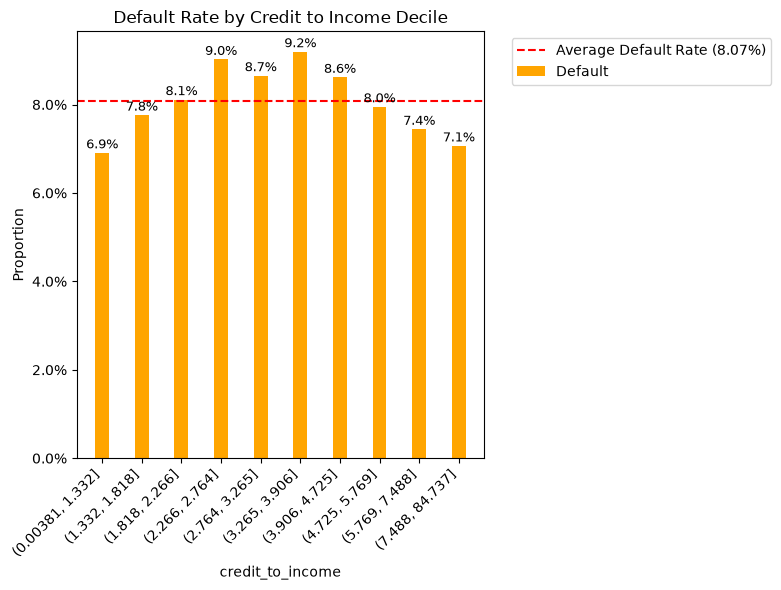

In [13]:
# Visualização de proporção de inadimplência por decil da relação crédito/renda
plot_target_by_decile(df_features, "credit_to_income", "TARGET","Default Rate by Credit to Income Decile" )

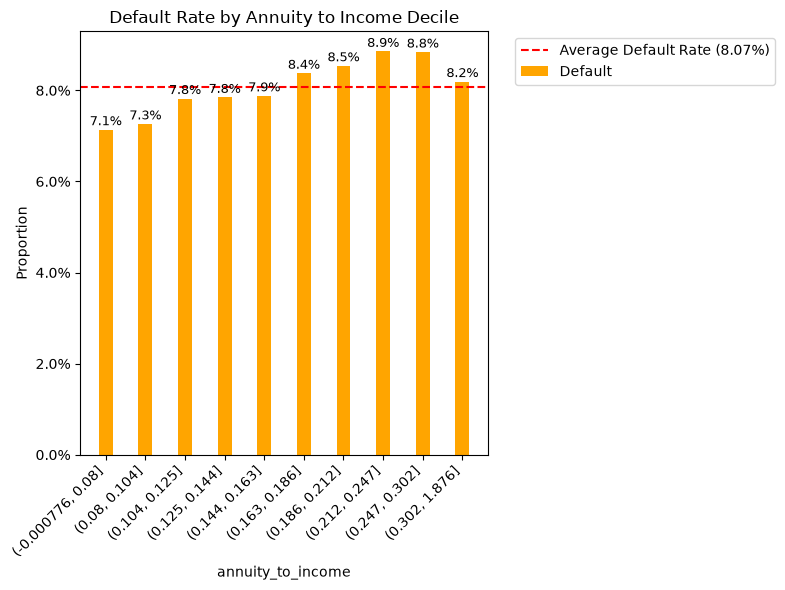

In [14]:
"""
Threshold empírico de 16%, significativamente abaixo dos padrões regulatórios de mercado (30-43%), possivelmente devido a origem dos dados serem de mercados emergentes
Temos uma distribuição linear até a inflexão encontrada em D9, apresentando uma relação positiva
"""
plot_target_by_decile(df_features, "annuity_to_income", "TARGET", "Default Rate by Annuity to Income Decile")


# Criação de Features e teste

Criando hipóteses e verificando como ela se comporta em relação ao 'TARGET' buscando correlação para o default

## Criação de hipóteses

1. Clientes com 4 filhos apresentam taxa de default 66% maior que clientes sem filhos, refletindo uma maior pressão financeira por dependentes
2. Clientes com um nível educacional "Lower secondary" apresenta uma taxa de default 204% maior em relação aos clientes com "Higher education", isso se deve aos maiores salários associados a usuários com mais educação e a estabilidade que a educação fornece, além de uma melhor educação financeira
3. Clientes com uma taxa de credit_to_income no intervalo de 3,2 a 3,9 tem ua taxa de default 33% maior que clientes no primeiro decil e uma taxa de 29% maior que clientes no último decil. Isso se deve ao crédito representar uma pequena parcela da renda do primeiro decil dos clientes e, no topo o banco faz uma maior triagem do cliente, resultando em menos clientes que são aceitos, mas os que são aceitos tendem a cumprir, no meio se concentra as maiores porcentagens de default por ser um valor considerável da renda do cliente como dívida e por se tratar do cliente médio, que assume um valor de crédito com um nível de exposição maior
4. Clientes com baixo EXT_SOURCE_2 apresentam taxa de default significativamente maior, com relação monotonicamente decrescente entre score e default, a média do score é 0.523 para clientes adimplentes contra 0.411 para inadimplentes, gap de 0.11 numa escala de 0 a 1, o maior sinal preditivo individual do dataset. O EXT_SOURCE consolida histórico de crédito em fontes externas (bureaus), por isso concentra tanto poder preditivo. Adicionalmente, a ausência do score também prediz: clientes sem EXT_SOURCE_1 (56% da base) apresentam 8.52% de default contra 7.50% de quem tem (14% mais chance em termos relativos), com padrão similar em EXT_SOURCE_3.
5. Clientes com maior comprometimento de renda pela parcela apresentam taxa de default crescente do D1 (7.14%) ao D9 (8.84%), aumento de 24%, seguindo relação aproximadamente linear. No último decil observa-se inflexão para 8.19%, clientes que conseguem crédito com comprometimento muito alto em relação à renda passaram por triagem  mais rigorosa.
 

In [15]:
df_features.groupby("NAME_EDUCATION_TYPE")['TARGET'].agg(["mean", "count"])

,mean,count
NAME_EDUCATION_TYPE,,
Academic degree,0.018293,164
Higher education,0.053551,74863
Incomplete higher,0.084850,10277
Lower secondary,0.109277,3816
Secondary / secondary special,0.089399,218391


In [16]:
df_features.groupby("CNT_CHILDREN")['TARGET'].agg(["mean", "count"])

,mean,count
CNT_CHILDREN,,
0,0.077118,215371
1,0.089236,61119
2,0.087218,26749
3,0.096314,3717
4,0.128205,429
5,0.083333,84
6,0.285714,21
7,0.000000,7
8,0.000000,2


In [17]:
"""
Análise de possíveis features para análise de risco de crédito:

CNT_CHILDREN / INCOME_TOTAL -> possível feature para análise de risco
AMT_CREDIT / AMT_GOODS_PRICE -> possível feature, compara o valor do bem que vai ser adquirido com o valor do emprestimo
AMT_GOODS_PRICE  / INCOME_TOTAL -> possível feature, valor do bem que vai ser adquirido pelo valor que o cliente recebe de renda anual
'NAME_CONTRACT_TYPE' -> variável importante
'years_employed' -> variável criada dividindo a variável DAYS_EMPLOYED / 365.25 e tratando os valores para clientes aposentados/empregos informais, encontra-se uma variável com correlação negativa e boa para ser utilizada como feature


"""
df_description = desc[desc['Table'] == 'application_{train|test}.csv'][["Row", "Description"]].head(50)

df_description.head(100)


# df_description[df_description['Row'] == 'AMT_GOODS_PRICE'].values[0]

,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
5,FLAG_OWN_REALTY,Flag if client owns a house or flat
6,CNT_CHILDREN,Number of children the client has
7,AMT_INCOME_TOTAL,Income of the client
8,AMT_CREDIT,Credit amount of the loan
9,AMT_ANNUITY,Loan annuity


In [18]:
"""
Cash loans apresenta aproximadamente 90,4% dos casos no dataset (278232 emprestimos)
Revolving Loans apresenta aproximadamente 9,5 % dos casos no dataset (29279 emprestimos)

nesse caso o número de inadimplencia tende a ser menor em Revolving Loans devido a alta taxa de juros associados e a maneira de cobrança que 
é recorrente onde o cliente paga apenas o que foi utilizado no mês

"""


df_features['NAME_CONTRACT_TYPE'].value_counts(normalize = True)

type_contract_per_target = pd.crosstab(df_features['NAME_CONTRACT_TYPE'], df_features['TARGET'], normalize = 'index')

display(type_contract_per_target.style.format("{:.2f}"))

print(df_features['NAME_CONTRACT_TYPE'].value_counts(normalize= True)
)

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,0.92,0.08
Revolving loans,0.95,0.05


NAME_CONTRACT_TYPE
Cash loans         0.904787
Revolving loans    0.095213
Name: proportion, dtype: float64


In [19]:
# visualização do target para years_employed
print(df_features.groupby("TARGET")['DAYS_EMPLOYED'].mean())

# Max tem um valor muito a cima, isso se deve a carácterística do dataset em colocar o valor 365243 dias para clientes informais/aposentados
print(df_features['DAYS_EMPLOYED'].describe())

df_features['DAYS_EMPLOYED'].isna().sum()

TARGET
0    65696.146123
1    42394.675448
Name: DAYS_EMPLOYED, dtype: float64
count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


np.int64(0)

In [20]:
df_features = df_features.copy()

In [21]:
df_features["flag_employed"] = (
    df_features["DAYS_EMPLOYED"] != 365243
).astype(int)

df_features["DAYS_EMPLOYED"] = (
    df_features["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
)

df_features["years_employed"] = (
    df_features["DAYS_EMPLOYED"] / -365.25
)

# verificando se o nan foi aplicado 
print("-" * 100)
print(df_features['DAYS_EMPLOYED'].isna().sum())


----------------------------------------------------------------------------------------------------
55374


In [22]:
df_features['flag_employed'].value_counts()

flag_employed
1    252137
0     55374
Name: count, dtype: int64

In [23]:
"""
Visualização da taxa de inadimplência entre os empregos formal vs emprego informal/aposentados
- Sem emprego formal: ~5,3%
- Com emprego formal: ~8,6%

"""
print(df_features.groupby("flag_employed")["TARGET"].mean())

print ("-" * 100)

print(df_features.groupby("TARGET")["years_employed"].mean())

flag_employed
0    0.053996
1    0.086600
Name: TARGET, dtype: float64
----------------------------------------------------------------------------------------------------
TARGET
0    6.675264
1    4.968977
Name: years_employed, dtype: float64


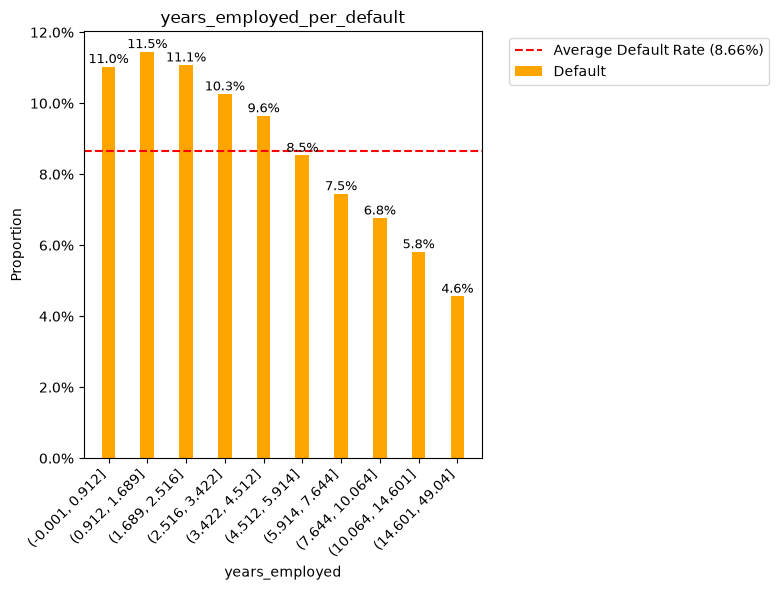

In [24]:
plot_target_by_decile(df_features, "years_employed","TARGET", "years_employed_per_default" )

In [25]:
df_features.groupby("TARGET")[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,0.511461,0.523479,0.520969
1,0.386968,0.410935,0.390717


In [26]:
df_features = df_features.assign (
    ext_source_1_missing = df_features['EXT_SOURCE_1'].isnull().astype(int),
    ext_source_2_missing = df_features['EXT_SOURCE_2'].isnull().astype(int),
    ext_source_3_missing = df_features['EXT_SOURCE_3'].isnull().astype(int)
)

In [27]:
"""
EXT_SOURCE_1 -> 56% dos clientes não tem esse score
EXT_SOURCE_2 -> 0,2% dos cliente não tem esse score
EXT_SOURCE_3 -> 19,1% dos clientes não tem esse score 
"""
print(df_features['ext_source_1_missing'].value_counts(normalize= True))

print("-" * 100)

print(df_features['ext_source_2_missing'].value_counts(normalize=True))

print("-" * 100)

print(df_features['ext_source_3_missing'].value_counts(normalize=True))

ext_source_1_missing
1    0.563811
0    0.436189
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
ext_source_2_missing
0    0.997854
1    0.002146
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
ext_source_3_missing
0    0.801747
1    0.198253
Name: proportion, dtype: float64


In [28]:
"""
Verificação dentro de cada grupo qual é a taxa de inadimplência

EXT_SOURCE_1
dif_absoluta = 1.02 pp
Quem não tem EXT_SOURCE_1 tem 14% mais chance de inadimplência comparado aos clientes que tem

EXT_SOURCE_2
dif_Absoluta = - 0,002 pp
Para esse score temos uma diferença percentual pequena, mas olhando a proporção de dados faltantes (0,2%) temos 
um desbalanceamento entre as classes

EXT_SOURCE_3
dif_absoluta = 1,6 pp
Quem não tem EXT_SOURCE_3 tem 20% mais chance de inadimplência comparado aos clientes que tem

"""
ext_source1_per_target = pd.crosstab(df_features['ext_source_1_missing'], df_features['TARGET'], normalize = 'index')

display(ext_source1_per_target)

print("-" * 100)

ext_source2_per_target = pd.crosstab(df_features['ext_source_2_missing'], df_features['TARGET'], normalize = 'index')

display(ext_source2_per_target)

print("-" * 100)

ext_source3_per_target = pd.crosstab(df_features['ext_source_3_missing'], df_features['TARGET'], normalize = 'index')

display(ext_source3_per_target)

TARGET,0,1
ext_source_1_missing,,
0,0.925045,0.074955
1,0.914805,0.085195


----------------------------------------------------------------------------------------------------


TARGET,0,1
ext_source_2_missing,,
0,0.919267,0.080733
1,0.921212,0.078788


----------------------------------------------------------------------------------------------------


TARGET,0,1
ext_source_3_missing,,
0,0.922335,0.077665
1,0.906881,0.093119


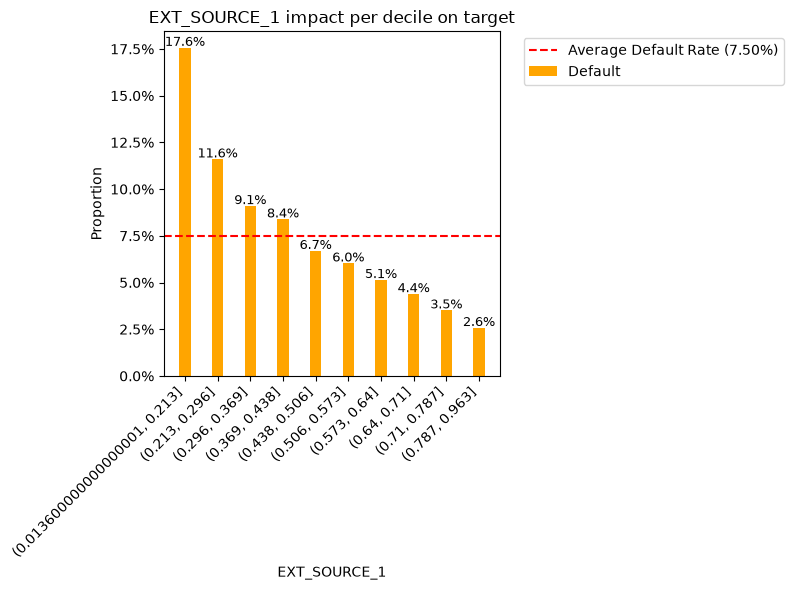

In [29]:
plot_target_by_decile(df_features, feature = "EXT_SOURCE_1", target= "TARGET", name="EXT_SOURCE_1 impact per decile on target")

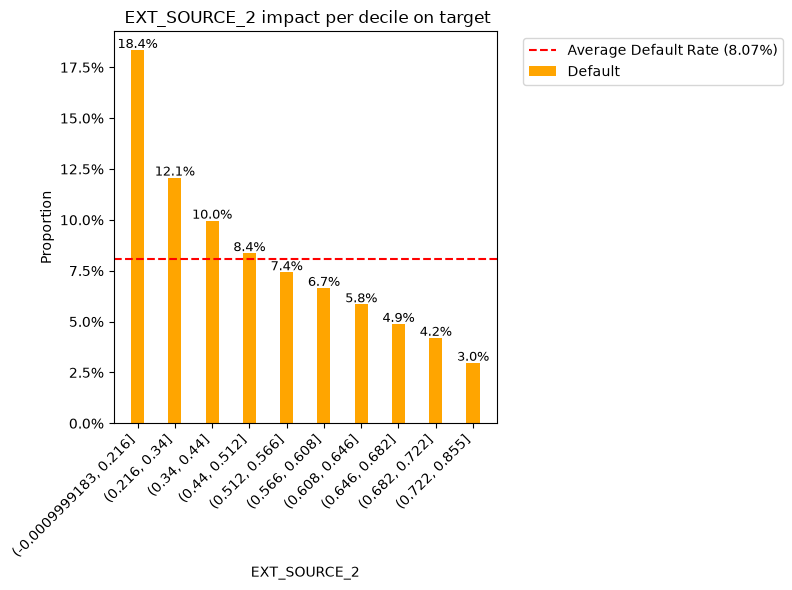

In [30]:
"""
Relação é monotônica negativa em relação a EXT_SOURCE_2, valores pequenos de EXT_SOURCE_2 se relacionam com mais clientes em default
"""
plot_target_by_decile(df_features, feature = "EXT_SOURCE_2", target = "TARGET",name= " EXT_SOURCE_2 impact per decile on target")

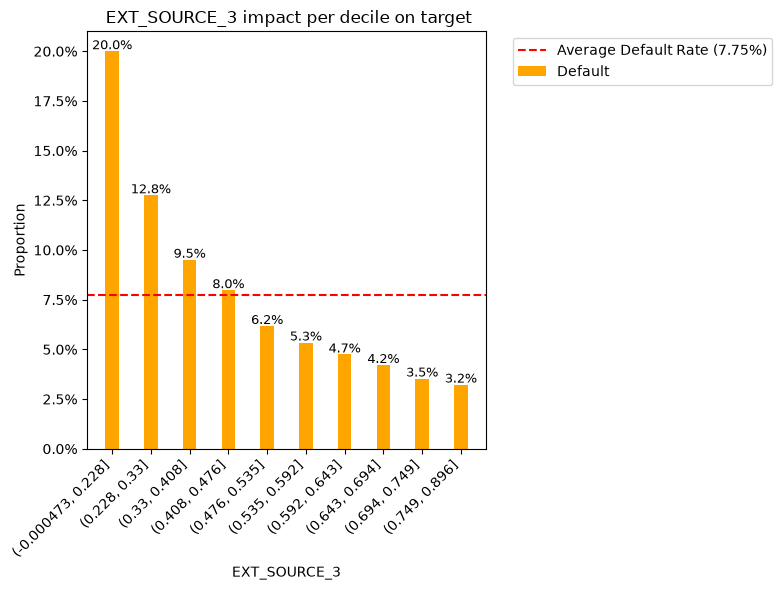

In [31]:
"""
Relação é monotônica negativa em relação a EXT_SOURCE_3, valores pequenos de EXT_SOURCE_3 se relacionam com mais clientes em default

"""
plot_target_by_decile(df_features, feature = "EXT_SOURCE_3", target = "TARGET",name= " EXT_SOURCE_3 impact per decile on target")

In [32]:
df_description_bureau = desc[desc['Table'] == 'bureau.csv'][["Row", "Description"]].head(50)

display(df_description_bureau.head(40))

df_description_bureau.iloc[4]['Description']


,Row,Description
122,SK_ID_CURR,ID of loan in our sample - one loan in our sam...
123,SK_BUREAU_ID,Recoded ID of previous Credit Bureau credit re...
124,CREDIT_ACTIVE,Status of the Credit Bureau (CB) reported credits
125,CREDIT_CURRENCY,Recoded currency of the Credit Bureau credit
126,DAYS_CREDIT,How many days before current application did c...
127,CREDIT_DAY_OVERDUE,Number of days past due on CB credit at the ti...
128,DAYS_CREDIT_ENDDATE,Remaining duration of CB credit (in days) at t...
129,DAYS_ENDDATE_FACT,Days since CB credit ended at the time of appl...
130,AMT_CREDIT_MAX_OVERDUE,Maximal amount overdue on the Credit Bureau cr...
131,CNT_CREDIT_PROLONG,How many times was the Credit Bureau credit pr...


'How many days before current application did client apply for Credit Bureau credit'

In [33]:
# Criação de features a partir do dataset do bureau
df_bureau["is_active"] = (df_bureau["CREDIT_ACTIVE"] == "Active").astype(int)

bureau_features = df_bureau.groupby("SK_ID_CURR").agg(
    bureau_count=("SK_ID_BUREAU", "count"),
    bureau_active_count=("is_active", "sum"),
    bureau_avg_credit=("AMT_CREDIT_SUM", "mean"),
    bureau_max_overdue=("AMT_CREDIT_MAX_OVERDUE", "max"),
    bureau_avg_overdue=("AMT_CREDIT_MAX_OVERDUE", "mean"),
    bureau_most_recent_days=("DAYS_CREDIT", "max"),
    bureau_oldest_days=("DAYS_CREDIT", "min"),
)
bureau_features["bureau_active_ratio"] = (
    bureau_features["bureau_active_count"] / bureau_features["bureau_count"]
)

In [34]:
"""
Criação do df_model com as features encontradas
"""
df_model = df_features.merge(bureau_features, how="left", on="SK_ID_CURR")

print(f"Linhas antes: {len(df_features)}")
print(f"Linhas depois: {len(df_model)}")
print(f"Duplicatas: {df_model['SK_ID_CURR'].duplicated().sum()}")

Linhas antes: 307511
Linhas depois: 307511
Duplicatas: 0


In [35]:
"""
Sinal para bureau_avg_credit, menor média de valor está associado a mais deffault
bureau_max_overdue, maior média está mais associado a default
bureau_avg_overdue, maior média está mais associado a default


""" 

bureau_cols = [
    "bureau_count", "bureau_active_count", "bureau_avg_credit",
    "bureau_max_overdue", "bureau_avg_overdue", "bureau_most_recent_days",
    "bureau_oldest_days", "bureau_active_ratio"
]
df_model.groupby("TARGET")[bureau_cols].mean().T



TARGET,0,1
bureau_count,5.556056,5.622545
bureau_active_count,2.021952,2.471328
bureau_avg_credit,383230.739263,316600.958111
bureau_max_overdue,9123.586625,12599.596089
bureau_avg_overdue,5024.772645,7799.731343
bureau_most_recent_days,-497.043710,-396.838816
bureau_oldest_days,-1781.189752,-1537.790848
bureau_active_ratio,0.406067,0.495395


In [36]:
"""
Analisando clientes com crédito anteriormente atrasado tem mais probabilidade de inadimplência 

Clientes que nunca atrasaram tem ~ 7,6% de default
Cliente que já atrasaram tem ~ 9,4% de default

Diferença absoluta de 1,8 e clientes que já atrasaram uma conta tem 26% mais chance de atrasar em relação a clientes que nunca atrasaram
"""
teve_atraso = (df_model["bureau_max_overdue"] > 0).astype(int)

df_model.groupby(teve_atraso)['TARGET'].agg(['mean', 'count'])

,mean,count
bureau_max_overdue,,
0,0.07650,237071
1,0.09496,70440


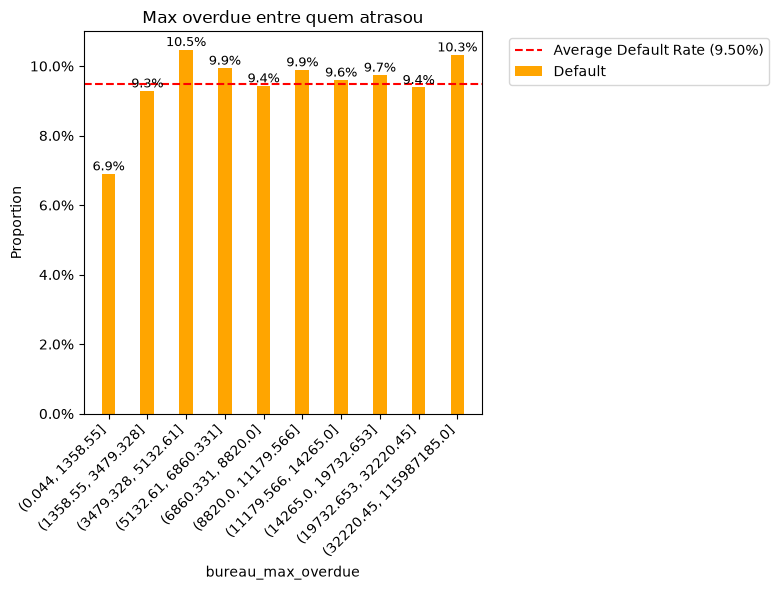

In [37]:
"""
Clientes que atrasaram sua dívida tem uma maior chance de não pagar caso sua dívida seja muito alta, entre os clientes do primeiro decil para o último decil há uma 
variação de 3,4 p.p e um aumento relativo de 49%, há uma inflexão no 3 decil que representa a maior porcentagem de clientes em inadimplência (10,5%)

"""

df_atrasos_positivos = df_model[df_model["bureau_max_overdue"] > 0]
plot_target_by_decile(df_atrasos_positivos, "bureau_max_overdue", "TARGET", "Max overdue entre quem atrasou")

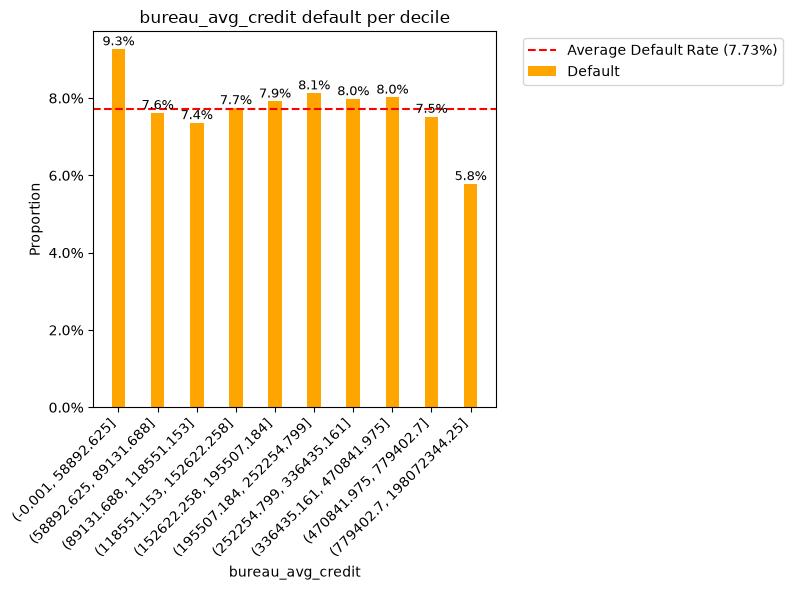

In [38]:


plot_target_by_decile(df_model, feature= "bureau_avg_credit", target= "TARGET", name = "bureau_avg_credit default per decile")

In [57]:
# testando o bureau_avg_credit dívido pela renda do usuário 
"""
Essa feature diminui a variação percentual do 2 decil ao 9, variando no máximo 2 p.p, e mantém a carácterística do primeiro decil 
concentrar a porcentagem de default e o último decil ter o menor valor sendo 3,6% de diferança absoluta entre eles 
"""

avg_credit_per_income = df_model["bureau_avg_credit"] / df_model["AMT_INCOME_TOTAL"]

df_model.groupby(pd.qcut(avg_credit_per_income, q=10, duplicates="drop"))["TARGET"].agg(["mean", "count"])

,mean,count
"(-0.001, 0.414]",0.089833,26349
"(0.414, 0.636]",0.076246,26349
"(0.636, 0.851]",0.078333,26349
"(0.851, 1.089]",0.078257,26349
"(1.089, 1.368]",0.078257,26349
"(1.368, 1.714]",0.075676,26349
"(1.714, 2.174]",0.077384,26349
"(2.174, 2.892]",0.078371,26349
"(2.892, 4.383]",0.076436,26349
"(4.383, 880.322]",0.064215,26349


In [40]:
"""
Clientes com uma maioria ativa das contas do bureau tem 66% mais chance de default em relação a clientes com uma minoria ativa, isso faz sentido
quanto maior a quantidade de contas abertas o cliente tem mais dificuldade de quitas suas dívidas
"""

active_group = pd.cut(
    df_model['bureau_active_ratio'],
    bins = [-0.01, 0, 0.5, 0.9, 1],
    labels= ['Nenhum ativo', 'minoria ativa', 'maioria ativa', "todos ativos"]
)
df_model.groupby(active_group)['TARGET'].agg(['mean','count'])

,mean,count
bureau_active_ratio,,
Nenhum ativo,0.056559,46341
minoria ativa,0.067892,144067
maioria ativa,0.108137,40199
todos ativos,0.110054,32884


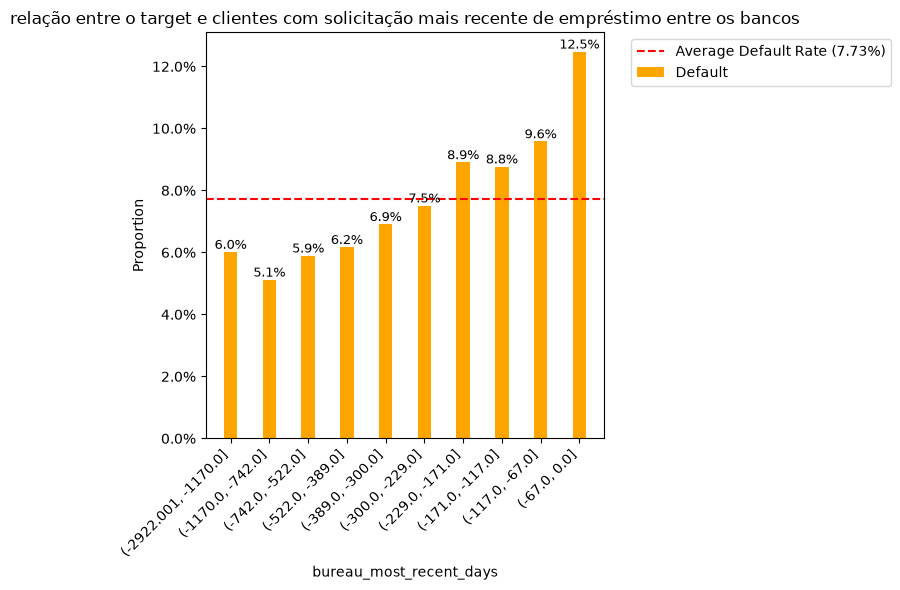

In [41]:
"""
Relação crescente com algumas inflexões no primeiro decil e no 7, 
revela que clientes que tentam um empréstimo no bureau e em um período pequeno de tempo no home_credit tem 12,5% de ser default
entre o 1 decil e o último tem-se uma variação de 6,5 p.p, ou seja, clientes que pediram empréstimo a uma período curto entre os bancos
tem 208% de chance de deafult em comparação com clientes com um pedido em um intervalo longo entre os bancos
"""

plot_target_by_decile(df_model, feature= "bureau_most_recent_days", target= "TARGET", name = "relação entre o target e clientes com solicitação mais recente de empréstimo entre os bancos")

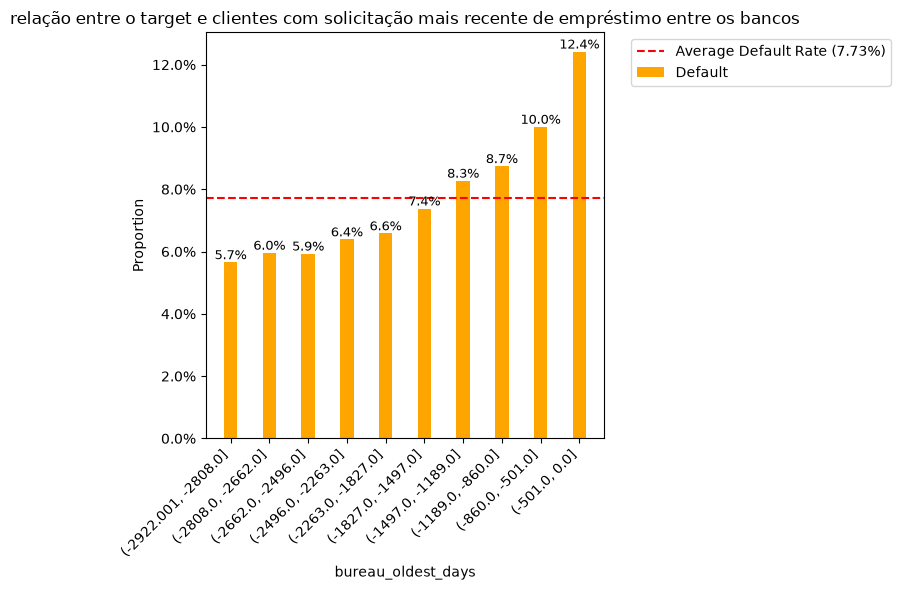

In [ ]:
"""
Relação linear com leve inflexão no segundo decil apenas de 1 p.p em relação ao 3 decil, depois segue 
de maneira crescente de uma maneira que clientes no último decil tem 217% maior chance de dafault em comparação a clientes do primeiro decil
tem uma diferença absoluta de 6,7 entre o 1 decil e o último
"""

plot_target_by_decile(df_model, feature= "bureau_oldest_days", target= "TARGET", name = "relação entre o target e clientes com solicitação mais antigas de empréstimo entre os bancos")

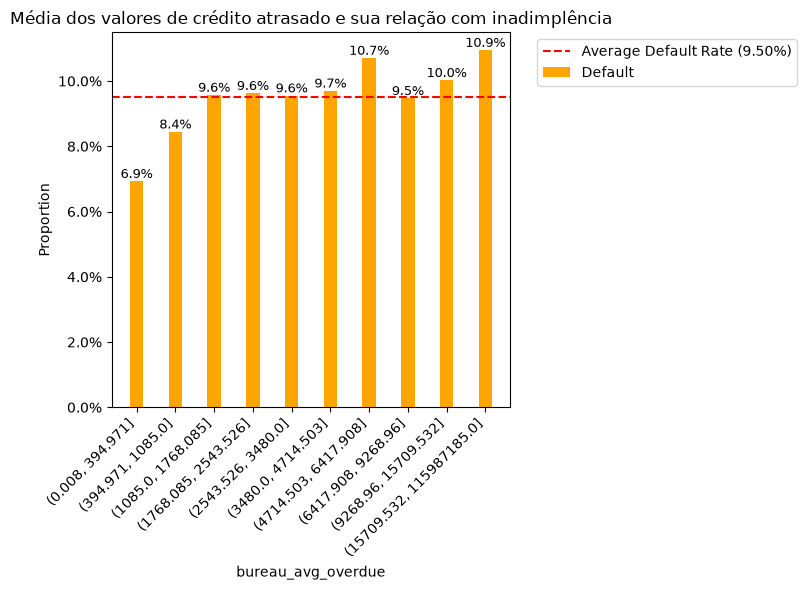

In [ ]:
"""
Entre os clientes que atrasaram uma conta o quanto a méda de atraso influência na inadimplência

A relação é crescente, começando no primeiro decil com 6,9% e estagnando no 3 a 6 decil um pouco a címa da média de deafult (9,6%)
Tem uma crescente aguda no 7 decil, alcançando 10,7% de default sendo um ponto de inflexão da variável que depois volta a crescer no último decil tendo o valor de 10.9%
comparando a primeira parcela com a última, há um aumento de 57,9% entre a ocorrência de inadimplência entre os clientes com maior média de crédito atrasado e menor média de crédito atrasado
diferença absoluta de 4 p.p
"""

df_com_atrasados = df_model[df_model['bureau_avg_overdue'] > 0]
plot_target_by_decile(df_com_atrasados, feature= 'bureau_avg_overdue', target = 'TARGET', name='Média dos valores de crédito atrasado e sua relação com inadimplência')